In [3]:
import sklearn
print("NumPy version:", np.__version__)
print("Scikit-learn imported successfully!")

NumPy version: 1.26.4
Scikit-learn imported successfully!


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("personality_dataset.csv")

In [9]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [13]:
#dataset contain 7 features and 1 target variable(Personality)

In [15]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [17]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

### Handle missing values

In [20]:
#deleting the rows with null values will throw away too much useful data.
#here the 'personality' column is 100% complete,so every column is valuable
#use the median to fill numerical null values and use mode to fill categorical null values

In [22]:
numerical_features = [
    'Time_spent_Alone', 'Social_event_attendance', 
    'Going_outside', 'Friends_circle_size', 'Post_frequency'
]

In [24]:
categorical_features = [
    'Stage_fear', 'Drained_after_socializing'
]

In [26]:
#fill numerical values
for col in numerical_features:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [28]:
#fill categorical values
for col in categorical_features:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

In [30]:
#verify that null values are gone
print(df.isnull().sum())

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


### Encode Categorical Values

In [33]:
binary_mapping = {'Yes': 1, 'No': 0}
df['Stage_fear'] = df['Stage_fear'].map(binary_mapping)
df['Drained_after_socializing'] = df['Drained_after_socializing'].map(binary_mapping)


In [35]:
#encode target column
df['Personality'] = df['Personality'].map({'Extrovert': 1, 'Introvert': 0})


In [37]:
#preview encoded data
print(df.head())

   Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0               4.0           0                      4.0            6.0   
1               9.0           1                      0.0            0.0   
2               9.0           1                      1.0            2.0   
3               0.0           0                      6.0            7.0   
4               3.0           0                      9.0            4.0   

   Drained_after_socializing  Friends_circle_size  Post_frequency  Personality  
0                          0                 13.0             5.0            1  
1                          1                  0.0             3.0            0  
2                          1                  5.0             2.0            0  
3                          0                 14.0             8.0            1  
4                          0                  8.0             5.0            1  


/var/folders/t9/2xjdnvmx7ps9fl22ymgnzptc0000gn/T/ipykernel_64868/3627881321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x='Personality', palette='Set2')


<function matplotlib.pyplot.show(close=None, block=None)>

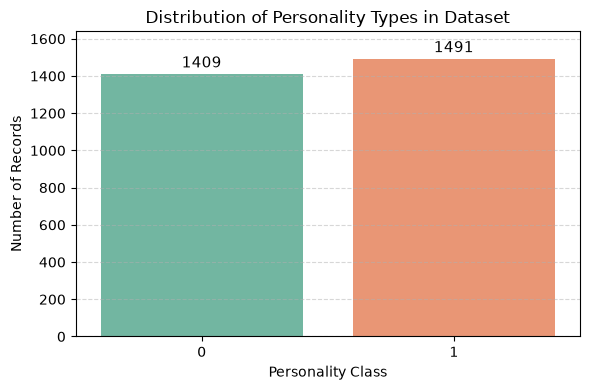

In [105]:
plt.figure(figsize=(6, 4))
ax=sns.countplot(data=df, x='Personality', palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')
    
plt.title('Distribution of Personality Types in Dataset')
plt.xlabel('Personality Class')
plt.ylabel('Number of Records')
plt.ylim(0, df['Personality'].value_counts().max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show

### split the dataset

In [40]:
#separate features(x) and target(y)
X = df.drop("Personality", axis=1)

y = df["Personality"]

In [42]:
#split dataset into 80% for training and 20% for testing
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model selection and training

In [47]:
#To compare and get most accurate model I decided to train using two models=random forest classifier and XGBoost classifier

In [51]:
#Why choose these 2 models
#Random Forest Classifier=It's a robust ensemble method and it trains multiple independent decision trees in parallel and average their predictions.
#This makes it highly resistant to overfitting and it's a perfect stable baseline
#XGBoost Classifier= It's a advanced gradient boost framework.Unlike random forest this builds trees sequentially where each new tree learns from and corrects the errors made by previous trees.
#This model represent industry standard for tabular performance nad optimization through gradient descent.

In [53]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [57]:
#Train XGBoost
!pip install xgboost

In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [61]:
#Compare two models

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [65]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ],
    "XGBoost": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred),
        recall_score(y_test, xgb_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Metric,Random Forest,XGBoost
0,Accuracy,0.918966,0.915517
1,Precision,0.929293,0.928814
2,Recall,0.913907,0.907285
3,F1,0.921536,0.917923


In [75]:
#Random Forest was selected as the deployment model after outperforming XGBoost across all evaluation metrics


In [79]:
#Feature importance
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

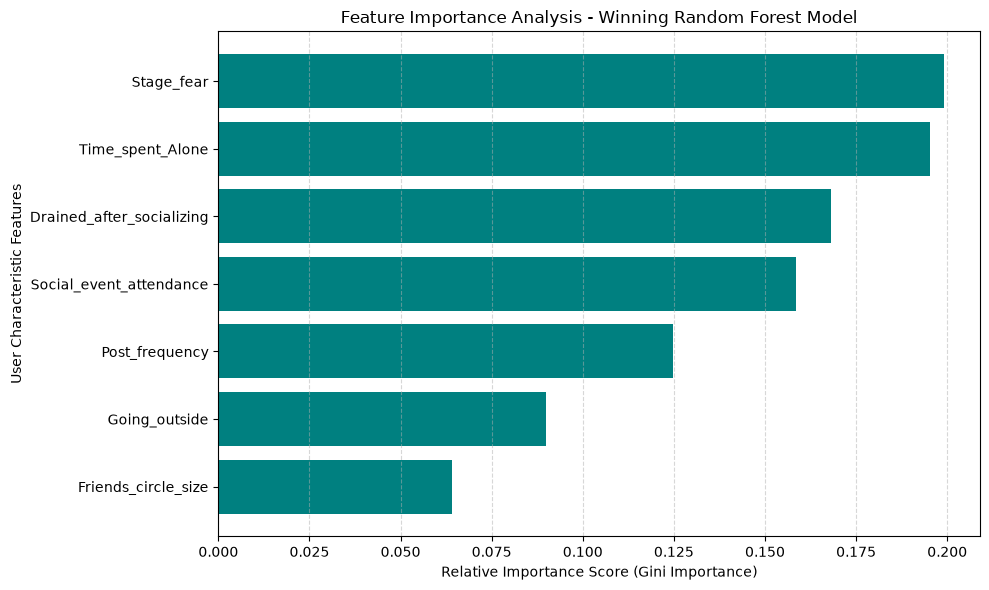

In [81]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Relative Importance Score (Gini Importance)')
plt.ylabel('User Characteristic Features')
plt.title('Feature Importance Analysis - Winning Random Forest Model')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [85]:
print("Exact Feature Importance Breakdown:")
print(importance_df.sort_values(by='Importance', ascending=False).to_string(index=False))

Exact Feature Importance Breakdown:
                  Feature  Importance
               Stage_fear    0.199038
         Time_spent_Alone    0.195191
Drained_after_socializing    0.168209
  Social_event_attendance    0.158622
           Post_frequency    0.124790
            Going_outside    0.089925
      Friends_circle_size    0.064226


### save the model

In [114]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(rf, file)